# Tablero

In [7]:
state = (2,8,3, 
         1,6,4, 
         7,0,5)

# Definir funcion para imprimir tablero

In [8]:
def print_board(state):
    """Imprime un estado del 8-puzzle en forma 3x3."""
    for r in range(3):
        row = state[r*3:(r+1)*3]
        print(" ".join("_" if x == 0 else str(x) for x in row))
    print()

In [9]:
initial = (2,8,3, 1,6,4, 7,0,5)
print_board(initial)

2 8 3
1 6 4
7 _ 5



# Paso 2 — Generar vecinos (movimientos del 0)

In [27]:
def get_neighbors(state):
    """
    Devuelve una lista de estados vecinos alcanzables desde 'state'
    moviendo el espacio vacío (0) arriba/abajo/izq/der.
    """
    neighbors = []

    zero_idx = state.index(0)           # dónde está el 0 (0..8)
    row, col = divmod(zero_idx, 3)      # índice -> (fila, col)

    moves = [(-1,0), (1,0), (0,-1), (0,1)]  # up, down, left, right
    
    for dr, dc in moves:
        new_row, new_col = row + dr, col + dc

        # validar límites del tablero
        if 0 <= new_row < 3 and 0 <= new_col < 3:
            new_idx = new_row * 3 + new_col

            new_state = list(state)
            # swap: intercambiar 0 con la ficha en new_idx
            new_state[zero_idx], new_state[new_idx] = new_state[new_idx], new_state[zero_idx]

            neighbors.append(tuple(new_state))

    return neighbors
    

In [28]:
print("Inicial:")
print_board(initial)

print("Vecinos:")
for n in get_neighbors(initial):
    print_board(n)

Inicial:
2 8 3
1 6 4
7 _ 5

Vecinos:
2 8 3
1 _ 4
7 6 5

2 8 3
1 6 4
_ 7 5

2 8 3
1 6 4
7 5 _



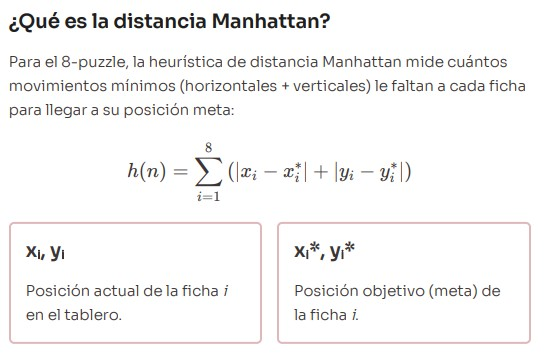

In [29]:
def manhattan(state, goal):
    """
    Distancia Manhattan para el 8-puzzle:
    suma para cada ficha (1..8) la distancia |dr|+|dc|
    entre su posición actual y su posición objetivo.
    """
    dist = 0
    for value in range(1, 9):  # ignoramos el 0
        cur_idx = state.index(value)
        goal_idx = goal.index(value)
        cur_r, cur_c = divmod(cur_idx, 3)
        goal_r, goal_c = divmod(goal_idx, 3)

        dist += abs(cur_r - goal_r) + abs(cur_c - goal_c)

    return dist

In [30]:
goal = (1,2,3, 8,0,4, 7,6,5)
print("h(initial) =", manhattan(initial, goal))
for n in get_neighbors(initial):
     print("h(vecino) =", manhattan(n, goal))
     print_board(n)

h(initial) = 5
h(vecino) = 4
2 8 3
1 _ 4
7 6 5

h(vecino) = 6
2 8 3
1 6 4
_ 7 5

h(vecino) = 6
2 8 3
1 6 4
7 5 _



# Paso 4 — Guardar “padres” y reconstruir el camino

In [31]:
def reconstruct_path(parent, start, goal):
    """
    Reconstruye el camino desde start hasta goal usando parent:
      parent[estado] = estado_anterior
    """
    path = []
    node = goal

    # Nos devolvemos desde goal hasta start usando parent
    while node != start:
        path.append(node)
        node = parent[node]  # retrocedemos
    path.append(start)

    path.reverse()
    return path

# Paso 5 — Estructuras de GBFS (open_list, visited)

GBFS necesita 2 cosas clave:
- **open_list**: una cola de prioridad (heap) con prioridad = ℎ(𝑛)
- **visited**: conjunto de estados ya expandidos (para no repetir)

Y un contador push_count para desempatar cuando dos estados tienen el mismo ℎ

# Paso 6 — Implementar GBFS (versión mínima y clara)

In [32]:
import heapq
import time

def greedy_best_first_search(start, goal, heuristic=manhattan, max_expansions=200000):
    """
    GBFS: prioriza SOLO h(n).
    Retorna (path, stats) o (None, stats).
    """
    t0 = time.time()

    open_list = []
    push_count = 0

    parent = {start: None}
    visited = set()

    expanded = 0
    generated = 0

    # metemos el inicio con prioridad h(start)
    heapq.heappush(open_list, (heuristic(start, goal), push_count, start))
    push_count += 1

    while open_list and expanded < max_expansions:
        h_val, _, current = heapq.heappop(open_list)

        # si ya lo expandimos antes, lo saltamos
        if current in visited:
            continue

        visited.add(current)
        expanded += 1

        # meta?
        if current == goal:
            t1 = time.time()
            path = reconstruct_path(parent, start, goal)
            stats = {
                "expanded": expanded,
                "generated": generated,
                "visited": len(visited),
                "time_sec": t1 - t0,
                "solution_depth": len(path) - 1
            }
            return path, stats

        # expandir vecinos
        for nxt in get_neighbors(current):
            generated += 1

            # si no lo hemos visto/registrado
            if nxt not in visited and nxt not in parent:
                parent[nxt] = current
                heapq.heappush(open_list, (heuristic(nxt, goal), push_count, nxt))
                push_count += 1

    # no encontró (o límite)
    t1 = time.time()
    stats = {
        "expanded": expanded,
        "generated": generated,
        "visited": len(visited),
        "time_sec": t1 - t0,
        "solution_depth": None,
        "stopped_reason": "open_list_empty" if not open_list else "max_expansions_reached",
    }
    return None, stats

In [33]:
initial = (2,8,3,
           1,6,4,
           7,0,5)

goal = (1,2,3,
        8,0,4,
        7,6,5)

path, stats = greedy_best_first_search(initial, goal, heuristic=manhattan)

print("Stats:", stats)

if path is None:
    print("No se encontró solución.")
else:
    print("Movimientos:", len(path)-1)
    for i, st in enumerate(path):
        print(f"Paso {i}:")
        print_board(st)

Stats: {'expanded': 6, 'generated': 15, 'visited': 6, 'time_sec': 0.0, 'solution_depth': 5}
Movimientos: 5
Paso 0:
2 8 3
1 6 4
7 _ 5

Paso 1:
2 8 3
1 _ 4
7 6 5

Paso 2:
2 _ 3
1 8 4
7 6 5

Paso 3:
_ 2 3
1 8 4
7 6 5

Paso 4:
1 2 3
_ 8 4
7 6 5

Paso 5:
1 2 3
8 _ 4
7 6 5



# Paso 7 — Implementar A* (versión mínima y clara)

In [34]:
def a_star(start, goal, heuristic):

    start_time = time.time()

    open_list = []
    counter = 0  # para desempatar en heap

    # g(n): costo acumulado real
    g_cost = {start: 0}

    # para reconstruir camino
    parent = {start: None}

    # insertamos estado inicial
    f_start = heuristic(start, goal)
    heapq.heappush(open_list, (f_start, counter, start))
    counter += 1

    expanded = 0

    while open_list:

        f_current, _, current = heapq.heappop(open_list)

        expanded += 1

        if current == goal:
            end_time = time.time()
            path = reconstruct_path(parent, start, goal)
            return path, {
                "expanded_nodes": expanded,
                "solution_depth": len(path) - 1,
                "time_seconds": end_time - start_time
            }

        for neighbor in get_neighbors(current):

            tentative_g = g_cost[current] + 1  # cada movimiento cuesta 1

            # Si nunca lo hemos visto o encontramos mejor camino
            if neighbor not in g_cost or tentative_g < g_cost[neighbor]:

                g_cost[neighbor] = tentative_g
                parent[neighbor] = current

                f_neighbor = tentative_g + heuristic(neighbor, goal)

                heapq.heappush(open_list, (f_neighbor, counter, neighbor))
                counter += 1

    return None, {"expanded_nodes": expanded}